In [80]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=20)
plt.rc('font', size=14)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

## BAO + CMB priors using likelihood : ``like_DESI_CMB_all.py``

In [22]:
fake_LCDM = False

### all redshifts

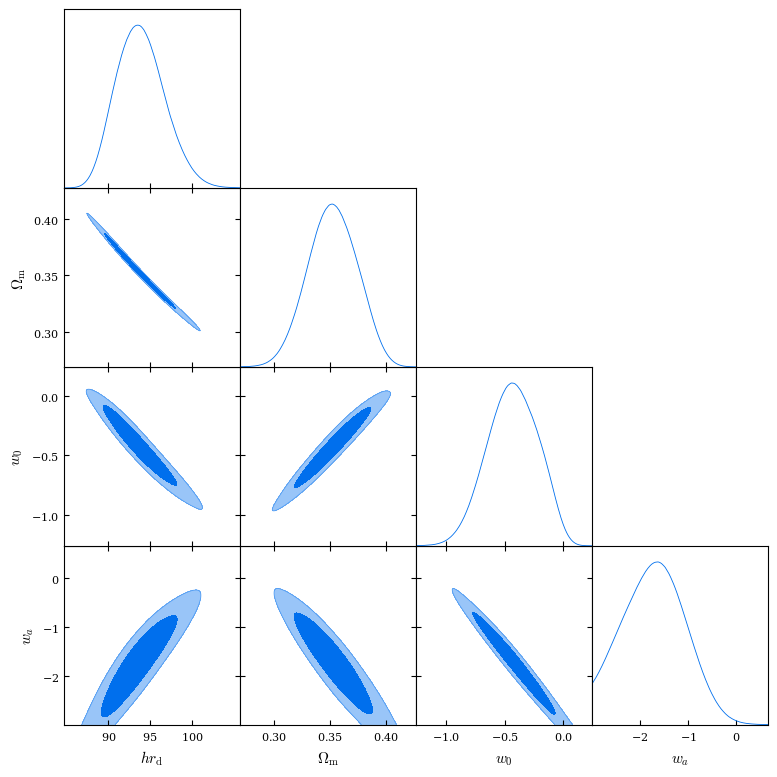

In [23]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run1' # forgot to add hrdrag in that one
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'
if fake_LCDM:
    path = r'C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'

samples = load_samples(path, to_getdist=True, skip=0.33)
varNames = ['hrdrag', 'omm', 'w', 'wa']

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(samples, varNames, filled=True)

In [26]:
cov_w_wa = samples.cov(['w', 'wa'])
print(cov_w_wa)
mean_w_wa = samples.mean(['w', 'wa'])
gauss_cnt = np.random.multivariate_normal(mean=mean_w_wa, cov=cov_w_wa, size=10000)

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(gauss_cnt[:, 0], gauss_cnt[:, 1])
print(f"wa = {slope:.2f} * w0 + {intercept:.2f}")

from scipy.optimize import curve_fit
def linear_model(x, a):
    return a * (x + 1)

popt, pcov = curve_fit(linear_model, gauss_cnt[:, 0], gauss_cnt[:, 1])
print(f"best fit slope (passing by LCDM) : {popt[0]:.2f}")

[[ 0.04654307 -0.13221194]
 [-0.13221194  0.39311921]]
wa = -2.84 * w0 + -2.93
best fit slope (passing by LCDM) : -2.97


### corner plot individual redshift

In [5]:
path1 = r"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2"
if fake_LCDM:
    path1 = r'C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'
# path2 = r"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z1_w_wa"
# path3 = r"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z4_w_wa"
# path_indiv = [rf"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z{z}_w_wa" for z in range(3, 8)]

names = ["hrdrag", "omm", "w", "wa"]
labels = ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", r"Ly$\alpha$"]

for z in range(1, 8):
    path = rf"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z{z}_w_wa"
    if fake_LCDM:
        path = rf"C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\individual_z\z{z}"
#     gd_sample = [load_samples(path, to_getdist=True, skip=0.33),
#                  load_samples(path1, to_getdist=True, skip=0.33)]
#     gdplot = gdplt.get_subplot_plotter()
#     gdplot.settings.title_limit_fontsize = 14
#     gdplot.triangle_plot(gd_sample, names, filled=True, legend_labels=[labels[z-1], "All redshifts"], 
#                         title_limit=1,
#                         markers={names[2]: -1, names[3]: 0},
#                         marker_args={"lw": 1})

### individual redshifts in $w_0 - w_a$ plane

In [84]:
fake_LCDM = False

In [85]:
varNames = ['hrdrag', 'omm', 'w', 'wa']

path_indiv = [rf"C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_individual\z{z}_w_wa" for z in range(1, 8)]
if fake_LCDM:
    path_indiv = [rf"C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\individual_z\z{z}" for z in range(1, 8)]

gd_sample = [load_samples(path, to_getdist=True, skip=0.33) for path in path_indiv] 

labels = ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", r"Ly$\alpha$"]
# order = [5, 3, 4, 6, 2, 0, 1]
order = [3, 5, 6, 4, 2, 0, 1]

# labels.append("All redshifts")
# order.append(7)
# gd_sample_.append(load_samples(path1, to_getdist=True, skip=0.33))

# gd_sample_ = [gd_sample[i] for i in order]
# labels_ = [labels[i] for i in order]
# gdplot = gdplt.get_single_plotter()
# gdplot.plot_2d(gd_sample_, varNames[2], varNames[3], filled=True, contour_lws=2)
# gdplot.add_legend(labels_, legend_loc='upper right')
# plt.axhline(0, color='k', ls='--')
# plt.axvline(-1, color='k', ls='--')
# plt.xlim(-2.5, 1.1)
# plt.ylim(-3, 0.2)

In [86]:
# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]   
print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 2286, 1547, 1856, 2354, 983, 1057, 1332


### plot of each z alone 

In [87]:
path1_fake = r'C:\EPFL\MA4\code\cobaya_runs\fake_data\Planck_flat_LCDM\exact\BAO+CMB_all_run1'
path1_DESI = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'
tot_sample_fake = load_samples(path1_fake, to_getdist=True, skip=0.33)
tot_sample_DESI = load_samples(path1_DESI, to_getdist=True, skip=0.33)

In [90]:
Save_fig = False

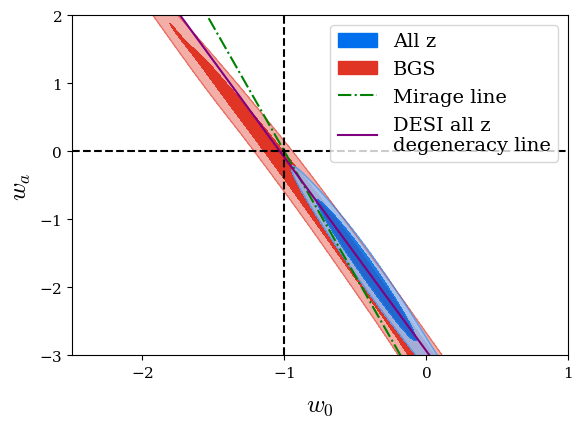

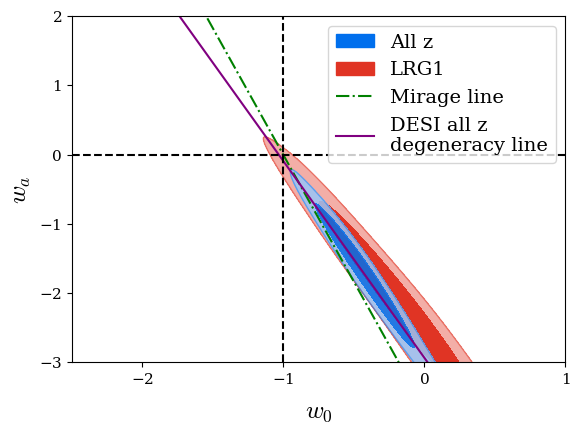

In [91]:
for i in range(2):
# for i in range(len(gd_sample)):
    sample_toplot = [gd_sample[i], tot_sample_fake if fake_LCDM else tot_sample_DESI]
    label_toplot = [labels[i], 'All z']
    gdplot = gdplt.get_single_plotter()
    gdplot.settings.axes_labelsize = 18
    gdplot.plot_2d(sample_toplot, varNames[2], varNames[3], filled=True, contour_lws=2)

    ax = plt.gca()
    x_line = np.linspace(-3, 1, 10)
    y_line = -3.66 * (x_line + 1)
    ax.plot(x_line, y_line, ls='-.', color='g')

    x_line = np.linspace(-3, 1, 10)
    y_line = -2.97 * (x_line + 1)
    y_line = -2.84 * x_line - 2.93
    ax.plot(x_line, y_line, ls='-', color='purple')

    ax.set_xlim(-2.5, 1)
    ax.set_ylim(-3, 2)
    ax.axhline(0, ls='--', color='k')
    ax.axvline(-1, ls='--', color='k')

    colors = gdplot.settings.solid_colors

    h1 = mpatches.Patch(color=colors[0], label=label_toplot[1])
    h2 = mpatches.Patch(color=colors[1], label=label_toplot[0])
    h3 = mlines.Line2D([], [], color='g', ls='-.', label='Mirage line')
    # h4 = mlines.Line2D([], [], color='purple', ls=':', label='Best fit line \n' + r'(passing by $\Lambda \mathrm{CDM}$)')
    h4 = mlines.Line2D([], [], color='purple', ls='-', label='DESI all z\ndegeneracy line')
    ax.legend(handles=[h1, h2, h3, h4], loc='upper right')
    # ax.legend(handles=[h1, h2, h3, h4], loc='lower left')

    # gdplot.add_legend(legend_labels=label_toplot, legend_loc='upper right')
    # plt.plot(x_line, y_line, ls='-.', color='g')
    # plt.xlim(-2.5, 0.7)
    # plt.ylim(-3, 2)
    # plt.axhline(0, ls='--', color='k')
    # plt.axvline(-1, ls='--', color='k')

    if Save_fig: 
        if fake_LCDM:
            gdplot.export(f'earlyCMB+BAO_z{i+1}_fake_LCDM.png', r'..\figures\fake_data\w_wa_individual\early_CMB')
        else:
            gdplot.export(f'earlyCMB+BAO_z{i+1}.png', r'..\figures\DESI_data\w_wa_individual\early_CMB')
